In [ ]:
# Drive'ı bağlıyoruz daha sonra kaydettiğimiz UniProtKB/Swiss-Prot veri setinin çekecez.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install transformers sentencepiece
!pip install transformers sentencepiece tf-keras
import os
# TensorFlow'u Keras 2 (Legacy) kullanmaya zorluyoruz. TF'nin yeni sürümleri
# keras 3' e geçtiği için HugginFace modelleriyle (Transformers) uyumsuzluk oluşturdu.
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [ ]:
# 1. Ortam Kurulumu ve Kütüphaneler
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

# modeller normalde 32 bit ile hesaplama yapar. bellek kulllanımını 16 bit'e
# indirdim. Hesaplama kolaylığı olsun diye.
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)


print(f"TensorFlow versiyonu: {tf.__version__}")
print(f"NumPy versiyonu: {np.__version__}")

# gpu'nun tensorflow tarafından görülüp görülmediğinin kontrolü.
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"gpu bulundu : {gpus}")
else:
    print(f"gpu bulunamadı, model cpu üzerinde eğitilecek")

TensorFlow versiyonu: 2.20.0
NumPy versiyonu: 2.0.2
gpu bulundu : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# 2. veri yükleme ve temizleme

# Colab için drive'dan veri setini alıyoruz sonra tabloyu pandasa aktar.
df = pd.read_csv('/content/drive/MyDrive/DerinOgrenme/uniprot_sprot.tsv.gz', sep='\t', compression='gzip')

# sadece dizi ve aile sütunlarını alıp boş olanları düşürüyoruz.
df = df[['Sequence', 'Protein families']].dropna()

# en sık rastlanan 50 protein ailesini seçerek veri setini daraltıyoruz.
top_50_families = df['Protein families'].value_counts().index[:50]

# metin halindeki protein aile isimlerini numaralandırıp indexledik.
df_filtered = df[df['Protein families'].isin(top_50_families)].copy()

# etiketleri (aileleri) sayısal değerlere dönüştürme
df_filtered['labels'] = df_filtered['Protein families'].astype('category').cat.codes
num_labels = len(df_filtered['Protein families'].unique())

print(f"filtrelenmiş veri seti boyutu : {df_filtered.shape}")
print(f"sınıf (aile) sayısı : {num_labels}")

filtrelenmiş veri seti boyutu : (57740, 3)
sınıf (aile) sayısı : 50


In [ ]:
# 3. Tokenizasyon. amino asit dizilerinin tokenize edilmesi

# AutoTokenizer yerine doğrudan BertTokenizer'ı dahil ediyoruz
from transformers import BertTokenizer

# aa'ların arasına boşluk ekle. nlp modelleri kelimeleri boşluklara göre ayırır.
# her aa'yı bir token olarak alacaz.
def add_spaces(sequence):
    return " ".join(list(sequence))
df_filtered['spaced_sequence'] = df_filtered['Sequence'].apply(add_spaces)

# proteinler için hazır eğitilmiş model olan Rostlab/prot_bert modelini indirdik.
# daha sonra bunun ağırlıklarını dondurup özellik çıkarımı yapacaz.
# aa'ların kısaltmaları A,C,T,G gibi büyük harf olduğu için bunları küçük harfe
# çeviremezsin. do_lower_case=False
tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert", do_lower_case=False)

# max dizi uzunluğunu 128 olarak belirledik. ilk 128 aminoasiti alıyoruz.
# proteinler çok uzun olabilir, belleği korumak için kırptık.
MAX_LEN = 128

# tüm veriyi tokenize etme
encoded_data = tokenizer(
    df_filtered['spaced_sequence'].tolist(),
    add_special_tokens=True,   # [CLS] ve [SEP] tokenlerını ekler
    max_length=MAX_LEN,
    padding='max_length',      # kısa olan aa'ları 128' e tamamla.
    truncation=True,           # aa'ları kırp
    return_tensors='np'        # TensorFlow tensorleri olarak döndür
)

input_ids = encoded_data['input_ids']
attention_masks = encoded_data['attention_mask']
labels = tf.convert_to_tensor(df_filtered['labels'].values)

print("tokenizasyon tamamlandı")
print(f"Input IDs shape: {input_ids.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizasyon tamamlandı
Input IDs shape: (57740, 128)


In [ ]:
# 4. train ve validation split ile veriyi bölme. %80 train, %20 validation.

# np.asarray() kullanarak verilerin scikit-learn'e KESİNLİKLE NumPy formatında girmesini sağlıyoruz.
# Böylece .numpy() veya tf.Tensor hatalarının tamamını bypass etmiş oluyoruz.
train_inputs, val_inputs, train_masks, val_masks, train_labels, val_labels = train_test_split(
    np.asarray(input_ids),
    np.asarray(attention_masks),
    np.asarray(labels),
    test_size=0.2,
    random_state=42     # kodun her çalıştığında verinin aynı şekilde bölünmesini garanti eder
)

# ileride pytorch özellik çıkarımı için kullanılacak batch size.
BATCH_SIZE = 16

print(f"Eğitim seti batch sayısı: {len(train_dataset)}")
print(f"Doğrulama seti batch sayısı:{len(val_dataset)}")

Eğitim seti batch sayısı: 2887
Doğrulama seti batch sayısı:722


In [ ]:
# 5. PyTorch ile Özellik Çıkarımı.
import torch
from transformers import BertModel
from tqdm import tqdm
import numpy as np

print("TensorFlow import hatası bypass ediliyor, özellikler PyTorch ile çıkarılıyor...")

# kullanıcak donanım.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# modeli pytorch formatında indirip doğrudan ekran kartına (GPU/cuda) gönder.
model_pt = BertModel.from_pretrained("Rostlab/prot_bert").to(device)

# Ağırlıkları donduruyoruz (eğitimi kapatıyoruz.) modeli sadece değerlendirme moduna alıp
# özellik çıkarımı yapacaz. 
model_pt.eval() 

# Batch'ler halinde işleyip RAM'i koruyan fonksiyon
def extract_features_pt(inputs, masks, batch_size=16):
    features = []
    num_samples = len(inputs)

    for i in tqdm(range(0, num_samples, batch_size)):
        # 4. hücrede oluşturduğumuz NumPy dizilerini PyTorch tensörüne çevirip GPU'ya yolluyoruz
        batch_inputs = torch.tensor(inputs[i:i+batch_size], dtype=torch.long).to(device)
        batch_masks = torch.tensor(masks[i:i+batch_size], dtype=torch.long).to(device)
        
        # pytorch'ta gradyan hesaplama yani türev almayı kapatıyoruz.
        with torch.no_grad():
            outputs = model_pt(batch_inputs, attention_mask=batch_masks)
            # [CLS] token'ını (ilk token) alıp NumPy dizisine çeviriyoruz
            cls_state = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            features.append(cls_state)

    return np.concatenate(features, axis=0)

print("Eğitim seti özellikleri çıkarılıyor...")
train_features = extract_features_pt(train_inputs, train_masks)

print("Doğrulama seti özellikleri çıkarılıyor...")
val_features = extract_features_pt(val_inputs, val_masks)

print("Özellikler başarıyla Google Drive'a kaydediliyor...")
np.save('/content/drive/MyDrive/DerinOgrenme/train_features.npy', train_features)
np.save('/content/drive/MyDrive/DerinOgrenme/val_features.npy', val_features)

# Scikit-learn ile böldüğümüz etiketleri de doğrudan kaydediyoruz
np.save('/content/drive/MyDrive/DerinOgrenme/train_labels_ext.npy', train_labels)
np.save('/content/drive/MyDrive/DerinOgrenme/val_labels_ext.npy', val_labels)

print("İşlem tamamen bitti! Hiçbir hata almadan 7. hücredeki TensorFlow eğitimine geçebilirsin.")

TensorFlow import hatası bypass ediliyor, özellikler PyTorch ile çıkarılıyor...


pytorch_model.bin:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/487 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: Rostlab/prot_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Eğitim seti özellikleri çıkarılıyor...



100%|██████████| 2887/2887 [24:02<00:00,  2.00it/s]


Doğrulama seti özellikleri çıkarılıyor...


100%|██████████| 722/722 [05:58<00:00,  2.01it/s]


Özellikler başarıyla Google Drive'a kaydediliyor...
İşlem tamamen bitti! Hiçbir hata almadan 7. hücredeki TensorFlow eğitimine geçebilirsin.


In [ ]:
""" !!! yedinci başlıkta eğitim yarıda kalırsa, sadece 1. hücre ve bu satırı
yeniden çalıştırıp tekrar 7. hücreyi çalıştıırıp eğitime kaldığın yerden
devam edebilirsin """

import numpy as np

# Kaydettiğimiz NumPy dizilerini (vektörleri) diskten geri okuyoruz.
train_features = np.load('train_features.npy')
train_labels_ext = np.load('train_labels_ext.npy')
val_features = np.load('val_features.npy')
val_labels_ext = np.load('val_labels_ext.npy')

print("Harika! Ağır işlemler atlandı, özellikler diskten anında yüklendi.")
print(f"Eğitim seti boyutu: {train_features.shape}")

In [ ]:
# 6. Hücre: Hızlı Eğitim (Yeni Sınıflandırıcı Başlık)
# özelliği pytorch ile çıkardık. şimdi sinir ağını tensorflow ile ile eğitecez.
import tensorflow as tf

# çıkardığımız özellik vektörlerini yeni train ve label set olarak atama ?????
train_labels_ext = train_labels
val_labels_ext = val_labels

# kaydettiğimiz özellik vektör boyutunu ProtBERT için ayarla (1024)
hidden_size = train_features.shape[1] # 1024 boyutlu özellik vektörü
num_labels = 50 

# keras katmanlı mimari
head_model = tf.keras.Sequential([
    # modele resim veya metin değil, düz sayılar (vektörler) gelecek.
    tf.keras.layers.Input(shape=(hidden_size,)),
    # Aşırı öğrenmeyi (overfitting) engellemek için küçük bir dropout.
    # ağdaki nöronların %10' ununu kapat. modelin eğitim verisini ezberlemesini
    # engelle. genelleme yeteneğini artır.
    tf.keras.layers.Dropout(0.1),
    # tek bir işlem katmanı kurdum. 1024 özellik girişli 50 protein sınıfına
    # karar veren bir çıkış katmanı.
    tf.keras.layers.Dense(num_labels)
])

# Sadece küçük bir Dense katmanı eğittiğimiz için öğrenme oranını biraz artırabiliriz.
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metric = tf.keras.metrics.SparseCategoricalAccuracy('accuracy')

head_model.compile(optimizer=optimizer, loss=loss, metrics=[metric])

# büyük bir model olan PortBERT modelini eğitseydik bathc_size 'ımızı küçük
# tutmak zorunda kalacaktık. ancak özellik vektörü çıkarıp modeli hafiflettiğimiz için
# bathc_size'ı yüksek tutabiliriz.
FAST_BATCH_SIZE = 64
EPOCHS = 3

print("hızlandırılmış eğitim modelimiz başlıyor...")
history = head_model.fit(
    train_features, train_labels_ext,
    validation_data=(val_features, val_labels_ext),
    batch_size=FAST_BATCH_SIZE,
    epochs=EPOCHS
)

Işık hızında eğitim başlıyor...
Epoch 1/3
722/722 [==============================] - 13s 9ms/step - loss: 1.4492 - accuracy: 0.7231 - val_loss: 0.7412 - val_accuracy: 0.8553
Epoch 2/3
722/722 [==============================] - 4s 6ms/step - loss: 0.6086 - accuracy: 0.8783 - val_loss: 0.5122 - val_accuracy: 0.9013
Epoch 3/3
722/722 [==============================] - 3s 5ms/step - loss: 0.4612 - accuracy: 0.9093 - val_loss: 0.4187 - val_accuracy: 0.9118


Doğrulama (Validation) seti üzerinde tahminler yapılıyor....
361/361 [==============================] - 1s 2ms/step
------------------------------
Doğruluk (Accuracy) Skoru    : 0.9118
Ağırlıklı F1 (Weighted F1) : 0.9185
------------------------------

Sınıflandırma Raporu (Classification Report):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       197
           1       1.00      0.99      0.99       477
           2       0.94      0.82      0.88       181
           3       0.99      0.86      0.92       198
           4       1.00      0.99      0.99       199
           5       0.82      0.56      0.67       168
           6       0.97      0.53      0.69       202
           7       1.00      0.99      1.00       248
           8       0.94      0.94      0.94       546
           9       0.99      0.93      0.96       768
          10       0.96      0.79      0.87       161
          11       0.99      0.95      0.97       39

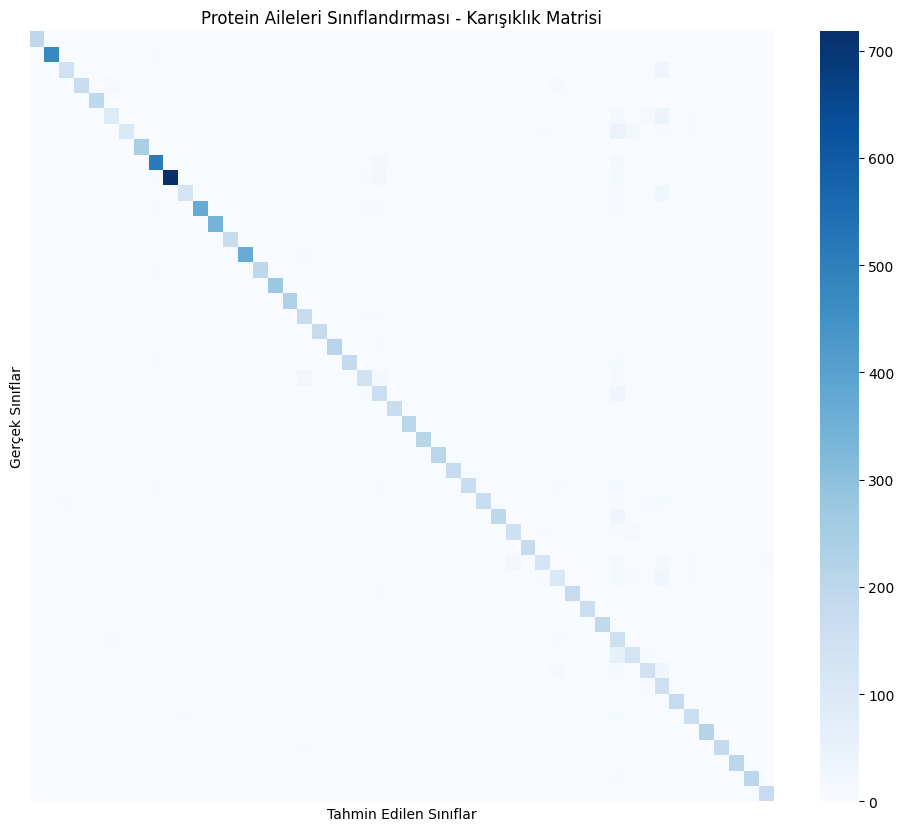

In [ ]:
# 7. modelin değerlendirilmesi ve metriklerin hesaplanması
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Doğrulama (Validation) seti üzerinde tahminler yapılıyor....")
# modelden tahminleri alma. ! artık head_model ve val_features kullanıyoruz.
predictions = head_model.predict(val_features)

# Dense çıktısı doğrudan ham skor olduğu için argmax ile en yüksek olasılıklı sınıfı seçiyoruz.
# yani en yüksek tahminli olanları seçiyoruz.
y_pred = np.argmax(predictions, axis=1)

# gerçek etiketleri özellik çıkarımı aşamasında kaydettiğimiz diziden alıyoruz.
y_true = val_labels_ext

# doğruluk ve ağırlık f1 skoru
accuracy = accuracy_score(y_true, y_pred)
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

print("-" * 30)
print(f"Doğruluk (Accuracy) Skoru    : {accuracy:.4f}")
print(f"Ağırlıklı F1 (Weighted F1) : {weighted_f1:.4f}")
print("-" * 30)

# detaylı sınıflandırma raporu
print("\nSınıflandırma Raporu (Classification Report):")
print(classification_report(y_true, y_pred))

# confusion matrisi görselleştirilmesi
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
# hangi protein ailelerinin birbiriyle karıştırıldığını görmek için Confusion
# Matris çizimi.
# 50 sınıfımız olduğu için xticklabels ve yticklabels'ı kapatarak daha temiz bir görüntü elde ediyoruz
sns.heatmap(cm, cmap='Blues', xticklabels=False, yticklabels=False)
plt.title('Protein Aileleri Sınıflandırması - Karışıklık Matrisi')
plt.ylabel('Gerçek Sınıflar')
plt.xlabel('Tahmin Edilen Sınıflar')
plt.show()